<a href="https://colab.research.google.com/github/khairuladib94/dl-food-research/blob/main/session-6/notebooks/03_spectroscopy_1dcnn_tensorflow_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study 3: NIR Spectroscopy Adulteration Detection with a Keras 1D CNN
Use `Conv1D` to scan spectral peaks and bands along wavelength.

> **Colab workflow:** Save a copy in Drive, then choose Runtime > Run all. The required teaching dataset downloads automatically; Google Drive is not mounted.



## Learning route

A spectrum is an ordered one-dimensional signal. A 1D CNN slides filters along wavelength to learn local bands and peak combinations.

![Neural-network patterns for different food data](https://github.com/khairuladib94/dl-food-research/blob/main/session-6/assets/session6-network-patterns.png?raw=1)

Unlike a 2D image filter, each kernel moves along only one axis: wavelength.


## 1. Prepare the notebook environment

We begin with the libraries used throughout the case study. Setting TensorFlow's log level before importing TensorFlow keeps the workshop output focused on the results.


In [16]:
from pathlib import Path
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


### Make the data portable

The next cell first looks for `spectra_adulteration.npz` beside the notebook. If the file is absent—as it will be in a fresh Colab session—it downloads the public workshop copy. This keeps the notebook runnable without mounting Google Drive.


In [17]:
# Portable workshop data setup: local Jupyter first, Colab fallback.
DATA_FILE = 'spectra_adulteration.npz'
LOCAL_DATA_DIR = Path('../data')
if (LOCAL_DATA_DIR / DATA_FILE).exists():
    DATA_DIR = LOCAL_DATA_DIR
    IN_COLAB = False
else:
    from urllib.request import urlretrieve
    try:
        import google.colab  # type: ignore  # noqa: F401
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False
    DATA_DIR = Path('/content/dl-food-research-data') if IN_COLAB else Path.cwd() / '.workshop-data'
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    target = DATA_DIR / DATA_FILE
    if not target.exists():
        url = 'https://raw.githubusercontent.com/khairuladib94/dl-food-research/main' + '/session-6/data/' + DATA_FILE
        print(f'Downloading {DATA_FILE} ...')
        urlretrieve(url, target)
    print(f'Dataset ready: {target}')


Dataset ready: /content/dl-food-research-data/spectra_adulteration.npz


### Make the experiment repeatable

Fixed random seeds make the teaching run easier to reproduce. The helper functions also keep splitting, standardisation, and training-history summaries consistent across the five examples.

> **Important:** standardisation statistics are calculated from the training set only. Using the test set here would leak information into the model.


In [18]:
SEED = 7
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)

def make_split(n, test_fraction=0.2):
    idx = np.arange(n)
    np.random.shuffle(idx)
    cut = int(n * (1 - test_fraction))
    return idx[:cut], idx[cut:]

def standardize(train, test, axis=0):
    mean = train.mean(axis=axis, keepdims=True)
    std = train.std(axis=axis, keepdims=True) + 1e-8
    return (train - mean) / std, (test - mean) / std, mean, std

def history_table(history):
    hist = pd.DataFrame(history.history)
    return hist.tail(5).round(4)


NumPy: 2.0.2
Pandas: 2.2.2
TensorFlow: 2.20.0
Keras: 3.13.2


### Set up reusable plots

These helpers turn Keras histories and classification results into readable diagnostics. They do not affect training; they only help us inspect what the model learned.


In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (8, 4.8),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10
})

def plot_history(history, metrics=None, title='Training history'):
    hist = pd.DataFrame(history.history)
    metrics = metrics or [c for c in hist.columns if not c.startswith('val_')]
    fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 4))
    if len(metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        ax.plot(hist.index + 1, hist[metric], label=f'train {metric}', linewidth=2)
        val_metric = f'val_{metric}'
        if val_metric in hist:
            ax.plot(hist.index + 1, hist[val_metric], label=f'validation {metric}', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend()
    fig.suptitle(title, y=1.03, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_binary_confusion(y_true, y_pred, labels, title='Confusion matrix'):
    cm = confusion_matrix(y_true.astype(int), y_pred.astype(int))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm


## 2. Load spectra and labels

Each row is one sample and each column is an absorbance value at a wavelength.


In [20]:
data = np.load(DATA_DIR / 'spectra_adulteration.npz')
wavelengths = data['wavelengths']
spectra = data['spectra'].astype('float32')
labels = data['labels'].astype('float32')


### Split and standardise each wavelength

Training statistics scale every wavelength. The final singleton dimension is the channel axis expected by `Conv1D`.


In [21]:
train_idx, test_idx = make_split(len(spectra))
X_train_raw, X_test_raw = spectra[train_idx], spectra[test_idx]
y_train, y_test = labels[train_idx], labels[test_idx]

X_train, X_test, spec_mean, spec_std = standardize(X_train_raw, X_test_raw, axis=0)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print('Spectra tensor:', X_train.shape)
pd.DataFrame({'wavelength_nm': wavelengths[:5], 'example_absorbance': spectra[0, :5]}).round(3)


Spectra tensor: (512, 260, 1)


,wavelength_nm,example_absorbance
0,900.000,0.428
1,906.178,0.401
2,912.355,0.391
3,918.533,0.344
4,924.710,0.393


### Compare authentic and adulterated curves

Raw curves help us see whether class differences are broad shifts or local spectral features.


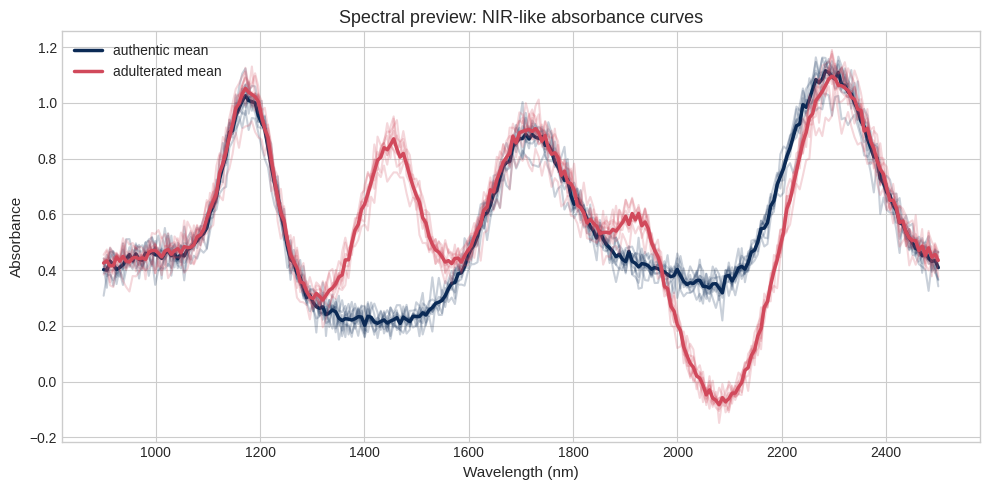

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
for cls, color, name in [(0, '#0B2A55', 'authentic'), (1, '#D1495B', 'adulterated')]:
    cls_idx = np.where(labels == cls)[0][:8]
    ax.plot(wavelengths, spectra[cls_idx].T, color=color, alpha=0.22)
    ax.plot(wavelengths, spectra[cls_idx].mean(axis=0), color=color, linewidth=2.5, label=f'{name} mean')
ax.set_title('Spectral preview: NIR-like absorbance curves')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorbance')
ax.legend()
plt.tight_layout()
plt.show()


## 3. Build the 1D CNN

Convolution kernels scan neighbouring wavelengths; pooling compresses the learned feature maps.


In [23]:
model = keras.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Conv1D(16, 9, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(32, 9, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.15),
    layers.Dense(1, activation='sigmoid')
])


### Configure binary classification

The sigmoid output estimates adulteration probability, trained with binary cross-entropy.


In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]
)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 260, 16)        │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 130, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 130, 32)        │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 65, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2080)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        66,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,425 (279.00 KB)

 Trainable params: 71,425 (279.00 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train and monitor

Validation curves reveal whether more epochs continue to improve unseen data.


In [25]:
history = model.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=22,
    batch_size=32,
    verbose=0
)
history_table(history)


,accuracy,loss,val_accuracy,val_loss
17,1.0,0.0000,1.0,0.0
18,1.0,0.0000,1.0,0.0
19,1.0,0.0000,1.0,0.0
20,1.0,0.0001,1.0,0.0
21,1.0,0.0000,1.0,0.0


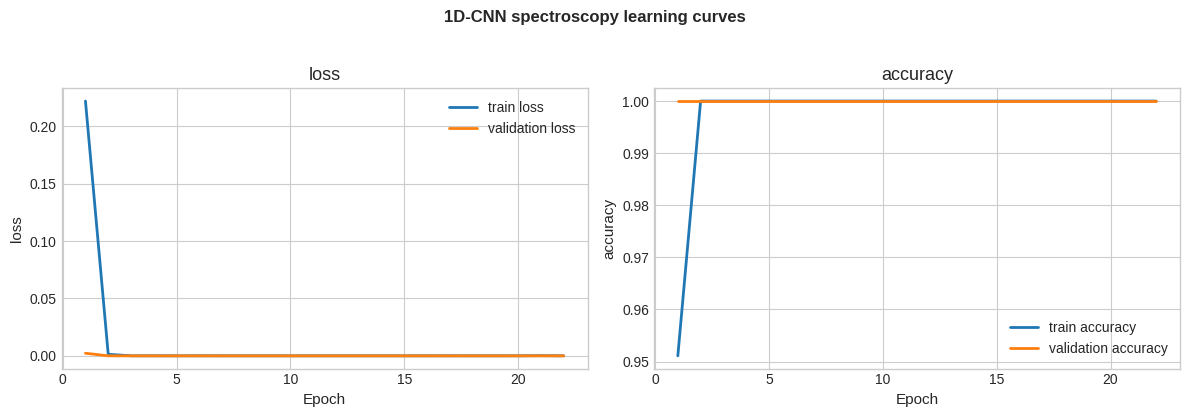

In [26]:
plot_history(history, metrics=['loss', 'accuracy'], title='1D-CNN spectroscopy learning curves')


## 5. Evaluate probabilities

Inspect both the aggregate accuracy and the probability assigned to individual spectra.


In [27]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
prob = model.predict(X_test[:12], verbose=0).ravel()
print(f'Test accuracy: {acc:.3f}')


Test accuracy: 1.000


### Inspect sample decisions

Thresholding at `0.5` converts probabilities into class predictions.


In [28]:
pd.DataFrame({
    'true_adulterated': y_test[:12].astype(int),
    'prob_adulterated': prob,
    'predicted_adulterated': (prob >= 0.5).astype(int)
}).round(3)


,true_adulterated,prob_adulterated,predicted_adulterated
0,1,1.0,1
1,1,1.0,1
2,0,0.0,0
3,0,0.0,0
4,1,1.0,1
5,0,0.0,0
6,1,1.0,1
7,0,0.0,0
8,1,1.0,1
9,0,0.0,0


### Separate correct and incorrect outcomes

The confusion matrix counts error types before we inspect how probability distributions overlap.


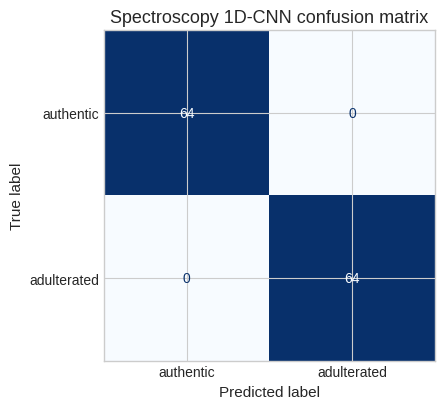

array([[64,  0],
       [ 0, 64]])

In [29]:
prob_full = model.predict(X_test, verbose=0).ravel()
pred_full = (prob_full >= 0.5).astype(int)
plot_binary_confusion(y_test, pred_full, labels=['authentic', 'adulterated'], title='Spectroscopy 1D-CNN confusion matrix')


### Relate predictions back to spectra

Probability overlap indicates ambiguous cases; plotted held-out curves reconnect predictions to the measured signal.


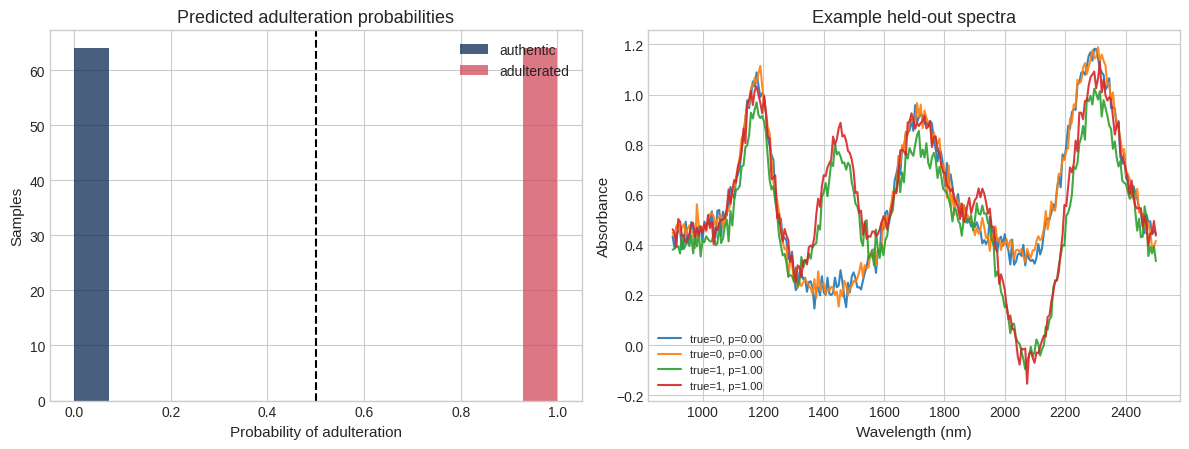

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].hist(prob_full[y_test == 0], bins=14, range=(0, 1), alpha=0.75, label='authentic', color='#0B2A55')
axes[0].hist(prob_full[y_test == 1], bins=14, range=(0, 1), alpha=0.75, label='adulterated', color='#D1495B')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Predicted adulteration probabilities')
axes[0].set_xlabel('Probability of adulteration')
axes[0].set_ylabel('Samples')
axes[0].legend()

example_ids = np.r_[np.where(y_test == 0)[0][:2], np.where(y_test == 1)[0][:2]]
for i in example_ids:
    raw_curve = (X_test[i, :, 0] * spec_std.ravel()) + spec_mean.ravel()
    axes[1].plot(wavelengths, raw_curve, label=f'true={int(y_test[i])}, p={prob_full[i]:.2f}', alpha=0.9)
axes[1].set_title('Example held-out spectra')
axes[1].set_xlabel('Wavelength (nm)')
axes[1].set_ylabel('Absorbance')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


## How to read the evidence

![Three complementary views of model quality](https://github.com/khairuladib94/dl-food-research/blob/main/session-6/assets/session6-evaluation-views.png?raw=1)

Learning curves describe optimization, predictions show sample-level behaviour, and error summaries expose the kinds of mistakes being made. A publishable conclusion needs all three, plus external validation that matches the intended use.


## Teaching notes
- Link important wavelength regions back to food chemistry.
- Compare against PLS-DA/PLSR baselines.
- External validation across instruments is more convincing than random row splits.